# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Yelly Ambarwaty
- **Email:** yellyelly729@gmail.com
- **ID Dicoding:** yelly_amb

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Di negara bagian (state) mana terdapat jumlah pelanggan terbanyak?
- Pertanyaan 2 : Bagaimana distribusi pelanggan di tingkat kota (city) untuk 10 kota dengan populasi pelanggan tertinggi?
- Pertanyaan 3 : Apakah terdapat pola persebaran pelanggan yang terkonsentrasi pada kode pos (zip code) tertentu?

## Import Semua Packages/Library yang Digunakan

In [7]:
!pip install gdown -q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
import zipfile
import os

## Data Wrangling

### Gathering Data

In [8]:
file_id = '1MsAjPM7oKtVfJL_wRp1qmCajtSG1mdcK'
output_zip_file = 'E-commerce-public-dataset.zip'

gdown.download(id=file_id, output=output_zip_file, quiet=True)

with zipfile.ZipFile(output_zip_file, 'r') as zip_ref:
     zip_ref.extractall('.')

customers_df = pd.read_csv('E-Commerce Public Dataset/customers_dataset.csv')
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


**Insight:**
- Data berhasil dimuat dari file E-commerce-public-dataset.zip yang kemudian dilakukan unzip hingga akhirnya bisa mengakses dataset yang akan digunakan yaitu customers_dataset.csv

- Data kemudian ditampilkan sebanyak 5 baris pertama menggunakan customers_df.head()

### Assessing Data

In [9]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [10]:
print("Jumlah duplikasi: ", customers_df.duplicated().sum())

Jumlah duplikasi:  0


In [11]:
customers_df.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


**Insight:**
- Tidak ditemukan adanya missing values pada seluruh kolom, sehingga integritas data dari sisi kelengkapan sangat baik.

- Terdapat ketidaksesuaian pada kolom customer_zip_code_prefix yang terdeteksi sebagai tipe data numerik (int64). Kolom ini seharusnya bertipe data string/object karena merupakan identitas lokasi.

- Tidak terdapat baris data yang duplikat (0 duplikasi), sehingga dapat dipastikan bahwa setiap entri adalah unik.

### Cleaning Data

In [12]:
customers_df['customer_zip_code_prefix'] = customers_df['customer_zip_code_prefix'].astype(str)
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  object
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: object(5)
memory usage: 3.8+ MB


In [13]:
customers_df['customer_city'] = customers_df['customer_city'].str.title()
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,Franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,Sao Bernardo Do Campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,Sao Paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,Mogi Das Cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,Campinas,SP


**Insight:**
- Kolom customer_zip_code_prefix telah berhasil diubah menjadi tipe data string untuk menjaga integritas data selama proses analisis dan visualisasi.

- Dilakukan proses Title Case pada kolom customer_city (misal: "sao paulo" menjadi "Sao Paulo"). Hal ini bertujuan untuk memastikan konsistensi penulisan nama kota sehingga saat proses visualisasi nanti, tidak terjadi penggandaan label akibat perbedaan format huruf.

## Exploratory Data Analysis (EDA)

### Explore Pelanggan Berdasarkan Wilayah Geografis (Region Mapping)

In [14]:
print(customers_df.describe(include="all"))

                             customer_id                customer_unique_id  \
count                              99441                             99441   
unique                             99441                             96096   
top     274fa6071e5e17fe303b9748641082c8  8d50f5eadf50201ccdcedfb9e2ac8455   
freq                                   1                                17   

       customer_zip_code_prefix customer_city customer_state  
count                     99441         99441          99441  
unique                    14994          4119             27  
top                       22790     Sao Paulo             SP  
freq                        142         15540          41746  


In [15]:
state_counts = customers_df.groupby(by="customer_state").customer_unique_id.nunique().sort_values(ascending=False).reset_index()
state_counts.rename(columns={"customer_unique_id": "customer_count"}, inplace=True)
print("\nJumlah Pelanggan per Negara Bagian:")
print(state_counts.head())


Jumlah Pelanggan per Negara Bagian:
  customer_state  customer_count
0             SP           40302
1             RJ           12384
2             MG           11259
3             RS            5277
4             PR            4882


In [16]:
city_counts = customers_df.groupby(by="customer_city").customer_unique_id.nunique().sort_values(ascending=False).reset_index()
city_counts.rename(columns={"customer_unique_id": "customer_count"}, inplace=True)
print("\n10 Kota dengan Pelanggan Terbanyak:")
print(city_counts.head(10))


10 Kota dengan Pelanggan Terbanyak:
           customer_city  customer_count
0              Sao Paulo           14984
1         Rio De Janeiro            6620
2         Belo Horizonte            2672
3               Brasilia            2069
4               Curitiba            1465
5               Campinas            1398
6           Porto Alegre            1326
7               Salvador            1209
8              Guarulhos            1153
9  Sao Bernardo Do Campo             908


In [17]:
region_mapping = {
    'SP': 'Southeast', 'RJ': 'Southeast', 'MG': 'Southeast', 'ES': 'Southeast',
    'RS': 'South', 'SC': 'South', 'PR': 'South',
    'MT': 'Central-West', 'MS': 'Central-West', 'GO': 'Central-West', 'DF': 'Central-West',
    'BA': 'Northeast', 'PE': 'Northeast', 'CE': 'Northeast', 'RN': 'Northeast',
    'AL': 'Northeast', 'PB': 'Northeast', 'SE': 'Northeast', 'PI': 'Northeast', 'MA': 'Northeast',
    'AM': 'North', 'PA': 'North', 'RO': 'North', 'RR': 'North', 'AC': 'North', 'TO': 'North', 'AP': 'North'
}

customers_df['region'] = customers_df['customer_state'].map(region_mapping)

total_unique = customers_df.customer_unique_id.nunique()
region_dist = customers_df.groupby(by="region").customer_unique_id.nunique().sort_values(ascending=False).reset_index()
region_dist.columns = ['region', 'customer_count']
region_dist['percentage'] = (region_dist['customer_count'] / total_unique * 100).round(2)

print("Tabel Distribusi Geografis Pelanggan:")
print(region_dist)

Tabel Distribusi Geografis Pelanggan:
         region  customer_count  percentage
0     Southeast           65900       68.58
1         South           13690       14.25
2     Northeast            9140        9.51
3  Central-West            5595        5.82
4         North            1794        1.87


**Insight:**
- Adanya perbedaan antara count (99.441) dan unique (96.096) pada customer_unique_id. Ini menunjukkan adanya pelanggan yang melakukan pembelian lebih dari satu kali (repeat order), meskipun rasionya masih relatif kecil. Hal ini menjadi peluang bagi bisnis untuk meningkatkan program retensi pelanggan di masa depan.

- Negara bagian SP (Sao Paulo) adalah basis pelanggan terbesar dengan jumlah 40.302 pelanggan unik. Angka ini jauh melampaui posisi kedua (RJ - Rio de Janeiro) yang memiliki 12.384 pelanggan. Dominasi SP mencapai lebih dari 40% dari total basis pelanggan, yang mengindikasikan bahwasannya aktivitas ekonomi dan jangkauan layanan e-commerce saat ini masih sangat terpusat di wilayah tersebut.

- Selaras dengan data negara bagian, kota Sao Paulo menempati urutan pertama dengan 14.984 pelanggan, diikuti oleh Rio de Janeiro (6.620) dan Belo Horizonte (2.672). Terlihat kesenjangan yang signifikan antara kota peringkat pertama dengan kota-kota lainnya, ini menunjukkan bahwa strategi pemasaran dan logistik harus sangat efisien di area metropolitan.

- Wilayah Southeast dapat disebut sebagai pasar utama yang sangat dominan, mencakup 68.58% (sekitar 65.900 pelanggan) dari total keseluruhan pelanggan. Hal ini menunjukkan bahwa konsentrasi bisnis dan jangkauan pasar saat ini masih sangat terpusat di wilayah tenggara Brasil.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_8015/1836394678.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(


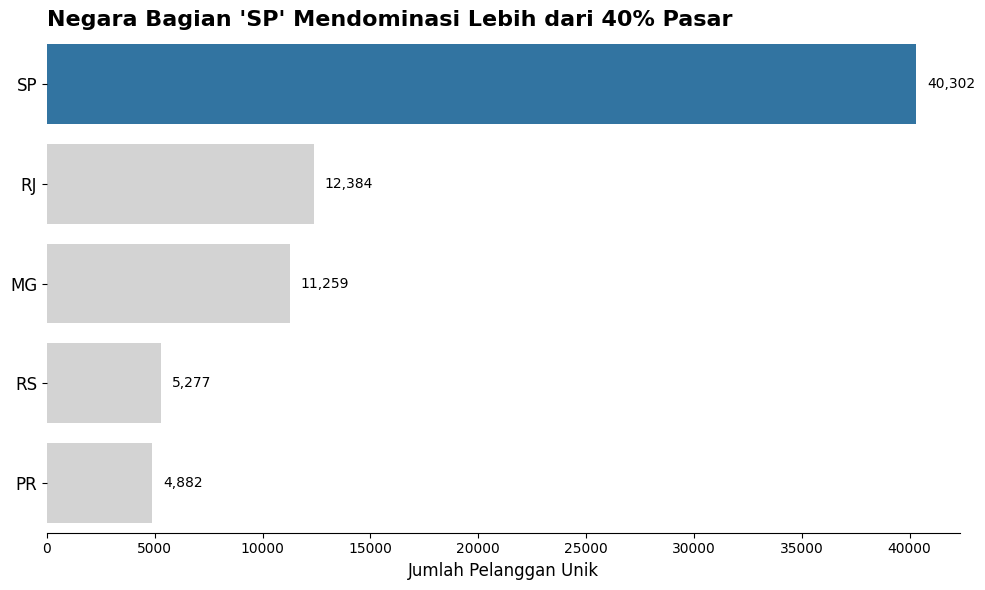

In [18]:
top_states_df = state_counts.head(5)

plt.figure(figsize=(10, 6))

colors_state = ["#1f77b4", "#d3d3d3", "#d3d3d3", "#d3d3d3", "#d3d3d3"]

ax1 = sns.barplot(
    x="customer_count",
    y="customer_state",
    data=top_states_df,
    palette=colors_state
)

plt.title("Negara Bagian 'SP' Mendominasi Lebih dari 40% Pasar", fontsize=16, fontweight='bold', loc='left')
plt.xlabel("Jumlah Pelanggan Unik", fontsize=12)
plt.ylabel(None)

for p in ax1.patches:
    width = p.get_width()
    plt.text(width + 500, p.get_y() + p.get_height() / 2, '{:,.0f}'.format(width), ha = 'left', va = 'center')

sns.despine(left=True, bottom=False)
plt.tick_params(axis='y', labelsize=12)
plt.tight_layout()
plt.show()

### Pertanyaan 2:

/tmp/ipykernel_8015/29051237.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(


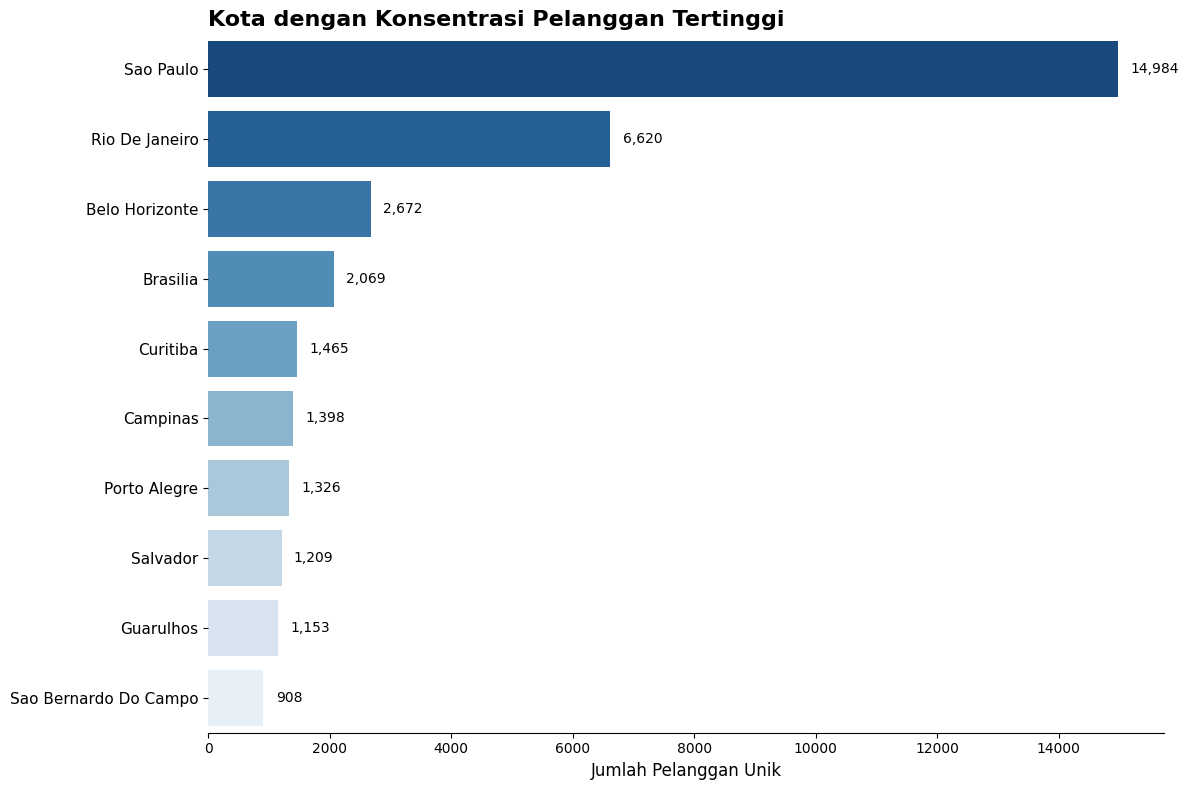

In [19]:
top_cities_df = city_counts.head(10)

plt.figure(figsize=(12, 8))

ax2 = sns.barplot(
    x="customer_count",
    y="customer_city",
    data=top_cities_df,
    palette="Blues_r"
)

plt.title("Kota dengan Konsentrasi Pelanggan Tertinggi", fontsize=16, fontweight='bold', loc='left')
plt.xlabel("Jumlah Pelanggan Unik", fontsize=12)
plt.ylabel(None)

for p in ax2.patches:
    width = p.get_width()
    plt.text(width + 200, p.get_y() + p.get_height() / 2, '{:,.0f}'.format(width), ha = 'left', va = 'center')

sns.despine(left=True, bottom=False)
plt.tick_params(axis='y', labelsize=11)
plt.tight_layout()
plt.show()

**Insight:**
- xxx
- xxx

### Pertanyaan 3:

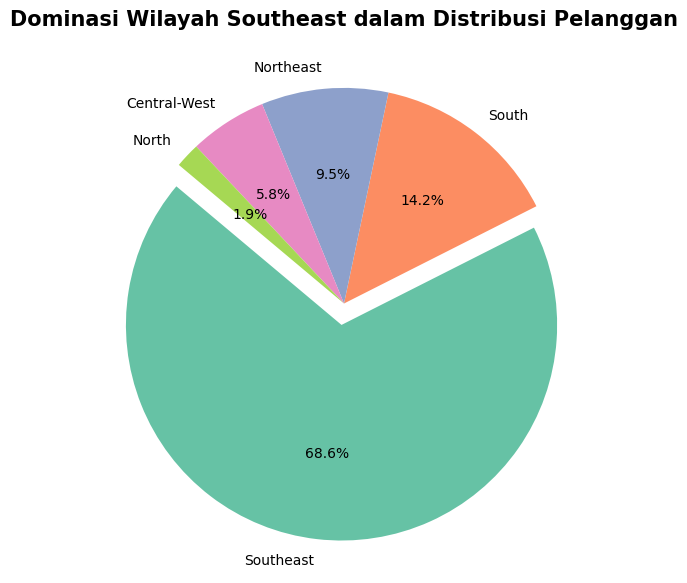

In [20]:
plt.figure(figsize=(10, 7))
colors_region = sns.color_palette("Set2")

# Membuat Pie Chart
plt.pie(
    region_dist['customer_count'],
    labels=region_dist['region'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors_region,
    explode=(0.1, 0, 0, 0, 0) # Menonjolkan wilayah Southeast (Peringkat 1)
)

plt.title("Dominasi Wilayah Southeast dalam Distribusi Pelanggan", fontsize=15, fontweight='bold')
plt.show()

**Insight:**
- Negara bagian SP (Sao Paulo) mendominasi pasar secara masif dengan 40.302 pelanggan, mencakup lebih dari 40% total basis pelanggan dan unggul sangat jauh dibandingkan negara bagian lainnya. Ini menegaskan bahwasannya SP adalah pusat ekonomi utama sekaligus fokus strategis terpenting bagi efisiensi logistik dan distribusi perusahaan.

- Kota Sao Paulo mendominasi pasar dengan 14.984 pelanggan unik, hampir dua kali lipat jika dibandingkan dengan Rio de Janeiro di posisi kedua. Konsentrasi yang sangat tinggi di kota metropolitan ini menunjukkan bahwa perusahaan sebaiknya memprioritaskan penempatan pusat distribusi dan penguatan logistik di area tersebut untuk mengoptimalkan biaya serta kecepatan pengiriman bagi mayoritas pelanggan.

- Wilayah Southeast mendominasi pasar dengan kontribusi sebesar 68,6%, yang menunjukkan bahwa lebih dari dua pertiga basis pelanggan terpusat di area tenggara. Sebaliknya, wilayah North memiliki penetrasi terendah hanya sebesar 1,9%, sehingga secara strategis perusahaan perlu memperkuat infrastruktur logistik di Southeast untuk menjaga stabilitas layanan, sembari mengevaluasi potensi ekspansi pasar di wilayah lain yang masih memiliki market share rendah.

## Analisis Lanjutan (Opsional)

## Conclusion

- Conclution pertanyaan 1: Berdasarkan hasil analisis, negara bagian SP (Sao Paulo) adalah wilayah dengan jumlah pelanggan terbanyak yang sangat dominan, mencapai 40.302 pelanggan. Jumlah ini jelas jauh melampaui negara bagian lainnya, yang membuat SP sebagai pusat pasar utama perusahaan.

- Conclution pertanyaan 2: Kota Sao Paulo menjadi basis pelanggan utama di tingkat kota dengan total 14.984 pelanggan unik. Konsentrasi pelanggan yang tinggi di kota metropolitan ini perlu memfokuskan operasional dan efisiensi logistik harus untuk diprioritaskan pada wilayah tersebut.

- Conclution pertanyaan 3: Dengan teknik manual clustering, ditemukan bahwa distribusi pelanggan terkonsentrasi sangat kuat di wilayah Southeast dengan angka mencapai 68,6%. Hal ini menunjukkan adanya ketimpangan distribusi pasar yang besar, di mana wilayah Utara (North) masih memiliki penetrasi pasar yang sangat rendah (1,9%).

In [22]:
customers_df.to_csv("main_data.csv", index=False)